## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

###Q1

1. Classification predicts categories or labels (like hot dog vs not hot dog). Regression predicts continuous numerical values (a house price based on the location coordinates and sqft).

2. A table showing True Positives, True Negatives, False Positives, and False Negatives. It helps identify specific types of errors such as which classes are being confused with others.

3. The ratio of correct predictions to total predictions. It can be insufficient if classes are imbalanced; a model could have 99% accuracy by just guessing the majority class and failing on the important minority class.

4. Root Mean Squared Error measures the average magnitude of the model's error. It penalizes larger errors more heavily because it squares the differences before averaging.

5. Overfitting happens when a model is too complex and learns noise in the training data and tends to fail on new data. Underfitting happens when a model is too simple to capture the underlying trend at all.

6. Using a separate test set allows you to evaluate how the model generalizes to unseen data. Selecting $k$ this way prevents you from picking a value that only works well because it 'memorized' the training set.

7. Reporting a label is simple and direct for decision-making. Reporting probabilities shows the model's confidence, allowing you to set custom thresholds.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [8]:
! git clone https://github.com/asomers205/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


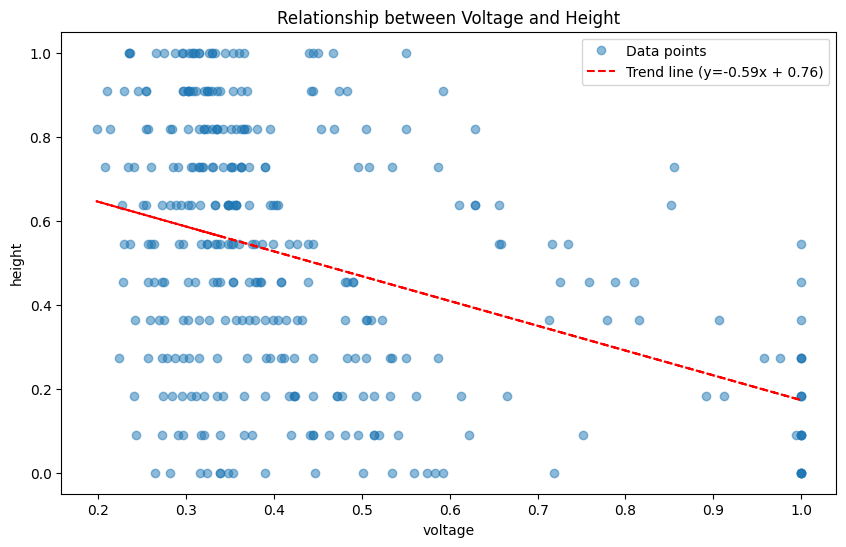

Target Label (mine_type) counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [9]:
# get the land_mines.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./data/land_mines.csv')
display(df.head())

# perform EDA

voltage = df['voltage']
height = df['height']

plt.figure(figsize=(10, 6))
plt.plot(voltage, height, 'o', alpha=0.5, label='Data points')

# add a trend line
z = np.polyfit(voltage, height, 1)
p = np.poly1d(z)
plt.plot(voltage, p(voltage), "r--", label=f"Trend line (y={z[0]:.2f}x + {z[1]:.2f})")

plt.xlabel('voltage')
plt.ylabel('height')
plt.title('Relationship between Voltage and Height')
plt.legend()
plt.show()

# summarize target label
print("Target Label (mine_type) counts:")
print(df['mine_type'].value_counts())

# describe table
display(df.describe())

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

# 2. split the sample 50/50
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# 3. build k-NN and select k
# evaluate k from 1 to 20 to find the best accuracy on the test set
ks = range(1, 21)
scores = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

best_k = ks[np.argmax(scores)]
print(f'Best k selected: {best_k} with accuracy: {max(scores):.4f}')

# 4. final model with best k
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print('\nConfusion Table:')
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=range(1,6), columns=range(1,6)))

print(f'\nOverall Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred))

Best k selected: 2 with accuracy: 0.4379

Confusion Table:
    1   2   3  4  5
1  25   0   6  4  1
2   0  32   0  3  0
3  12   2   9  6  4
4  12   5   8  8  0
5  15   2  10  5  0

Overall Accuracy: 0.4379

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

Dimensions: (2499, 3)
Missing values:
price      0
year       0
mileage    0
dtype: int64


,price,year,mileage
0,6300,2008,274117
1,2899,2011,190552
2,5350,2018,39590
3,25000,2014,64146
4,27700,2018,6654


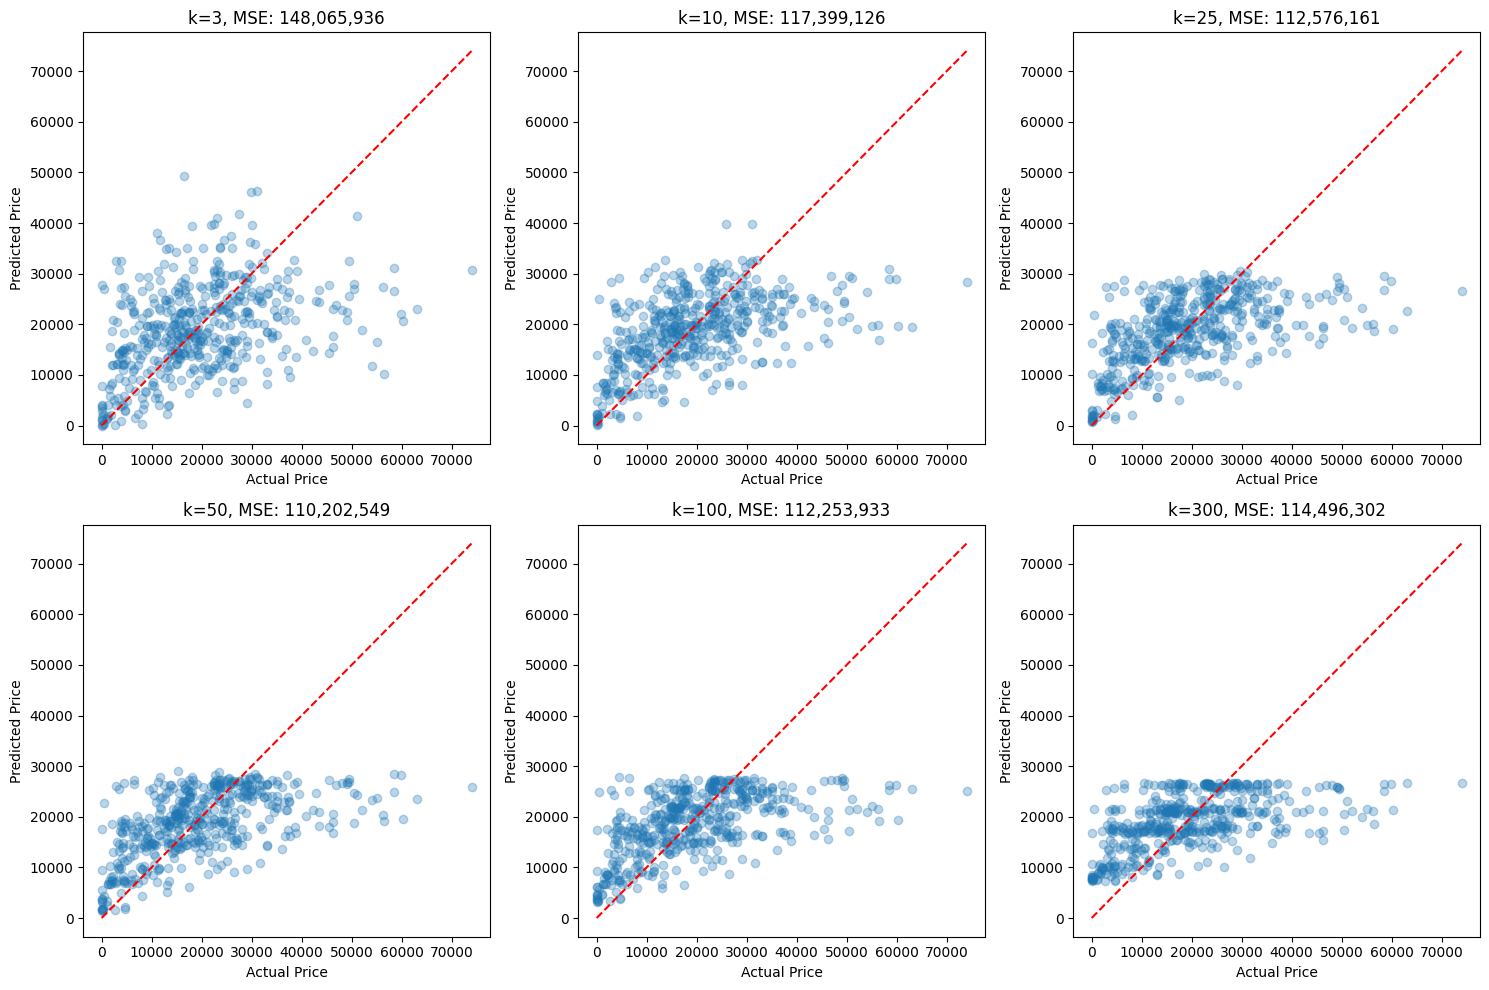

The optimal k is 50 with the lowest MSE.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# 1. Load data and select variables
df_cars = pd.read_csv('./data/USA_cars_datasets.csv')
df_cars = df_cars[['price', 'year', 'mileage']]
print(f"Dimensions: {df_cars.shape}")
print(f"Missing values:\n{df_cars.isnull().sum()}")
display(df_cars.head())

# 2. Maxmin normalize year and mileage
def max_min_norm(x):
    return (x - x.min()) / (x.max() - x.min())

X = df_cars[['year', 'mileage']].apply(max_min_norm)
y = df_cars['price']

# 3. Split the sample into ~80% training and ~20% evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. k-NN regression for various k values
ks = [3, 10, 25, 50, 100, 300]
mses = []

plt.figure(figsize=(15, 10))
for i, k in enumerate(ks):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    mses.append(mse)

    plt.subplot(2, 3, i+1)
    plt.scatter(y_test, preds, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'k={k}, MSE: {mse:,.0f}')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()

# 5. Determine optimal k
optimal_k = ks[np.argmin(mses)]
print(f"The optimal k is {optimal_k} with the lowest MSE.")

# 6. Description of results
# Observations on Overfitting and Underfitting:
# At low k (e.g., k=3), the model is prone to overfitting; predictions follow the noise in the training set closely, leading to high variance.
# At very high k (e.g., k=300), the model starts underfitting; predictions become less sensitive to local data patterns and cluster around the global mean, leading to high bias.
# The optimal k balances these two, minimizing the test MSE.

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Label: 7


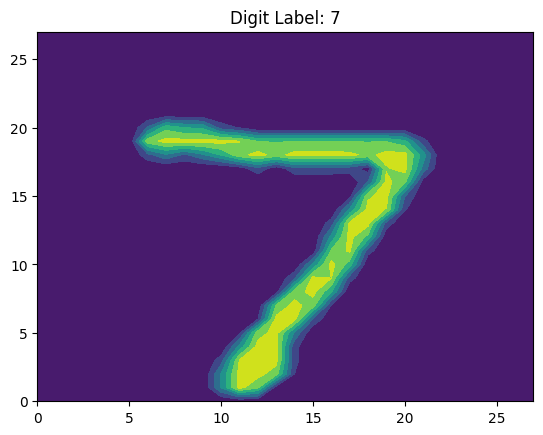

Label: 2


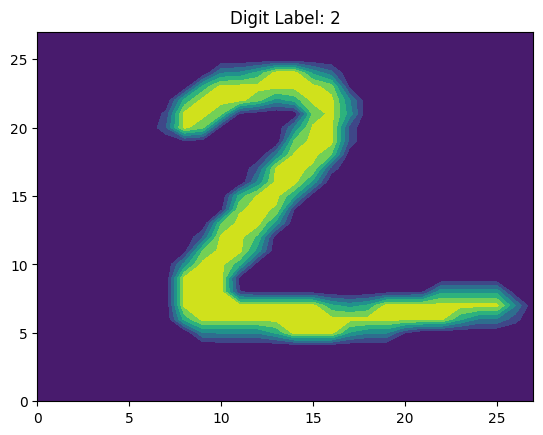

Label: 1


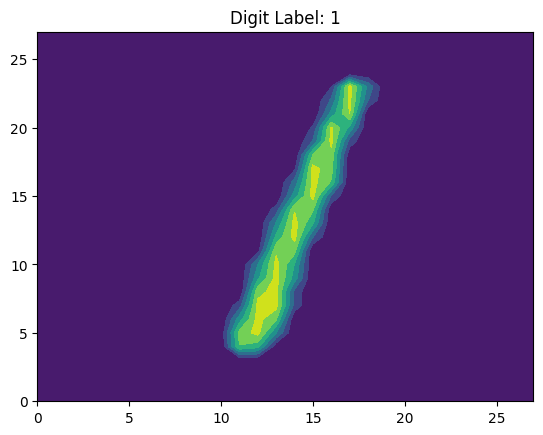

Label: 0


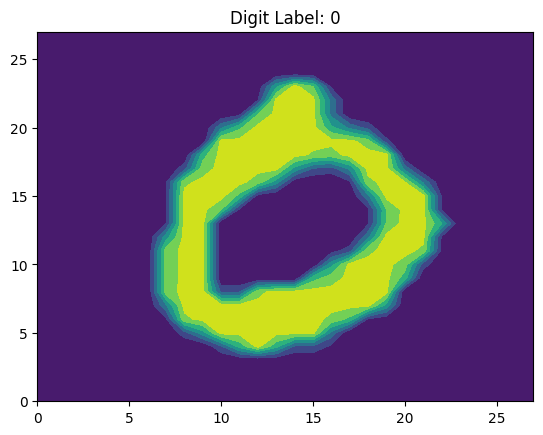

Label: 4


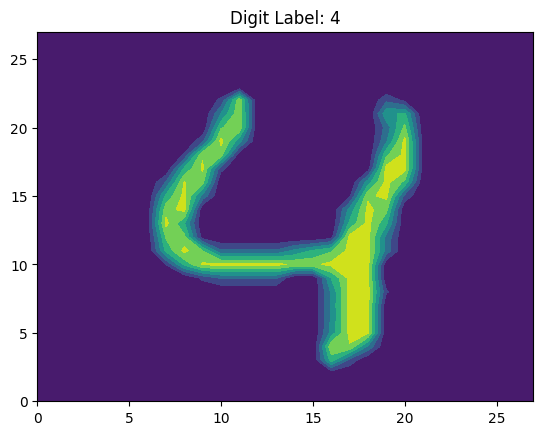

Shape of X_train: (60000, 28, 28)
Shape of X_test: (10000, 28, 28)
Shape of a single image (X_train[0]): (28, 28)
Shape of y_train: (60000,)
Shape of y_test: (10000,)


In [5]:
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# 1. load the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# visualize the first five numbers
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(f'Label: {y_test[i]}')
    plt.contourf(np.rot90(X_test[i].transpose()))
    plt.title(f'Digit Label: {y_test[i]}')
    plt.show()

# 2. shapes of the data
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of a single image (X_train[0]): {X_train[0].shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

In [6]:
# 3. reshape the training and testing data
# flatten 28x28 images into 784-length vectors
X_train_flat = X_train.reshape((X_train.shape[0], 784))
X_test_flat = X_test.reshape((X_test.shape[0], 784))

print(f'New shape of X_train: {X_train_flat.shape}')
print(f'New shape of X_test: {X_test_flat.shape}')

New shape of X_train: (60000, 784)
New shape of X_test: (10000, 784)


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd

# 4. Create a k-nearest neighbor classifier
# To speed up the search for k, we'll use a subset of the data
X_train_sub = X_train_flat[:10000]
y_train_sub = y_train[:10000]

ks = [1, 3, 5, 7]
scores = []

print('Evaluating k values...')
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sub, y_train_sub)
    score = knn.score(X_test_flat[:2000], y_test[:2000])
    scores.append(score)
    print(f'k={k}, accuracy={score:.4f}')

optimal_k = ks[np.argmax(scores)]
print(f'\nOptimal k found: {optimal_k}')

# 5. Performance on the test set
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)
final_knn.fit(X_train_sub, y_train_sub)
y_pred = final_knn.predict(X_test_flat[:2000])

print(f'\nFinal Accuracy: {accuracy_score(y_test[:2000], y_pred):.4f}')

# 6. Confusion Matrix and Patterns
print('\nConfusion Matrix:')
cm = confusion_matrix(y_test[:2000], y_pred)
cm_df = pd.DataFrame(cm, index=range(10), columns=range(10))
display(cm_df)

print('\nClassification Report:')
print(classification_report(y_test[:2000], y_pred))

Evaluating k values...
k=1, accuracy=0.9225
k=3, accuracy=0.9235
k=5, accuracy=0.9205
k=7, accuracy=0.9190

Optimal k found: 3

Final Accuracy: 0.9235

Confusion Matrix:


,0,1,2,3,4,5,6,7,8,9
0,175,0,0,0,0,0,0,0,0,0
1,0,234,0,0,0,0,0,0,0,0
2,5,5,196,0,0,0,3,8,2,0
3,0,1,1,189,0,4,2,4,3,3
4,0,3,0,0,203,0,2,0,1,8
5,2,0,0,7,1,163,1,2,0,3
6,2,1,0,0,1,1,173,0,0,0
7,0,11,0,1,2,1,0,186,0,4
8,3,4,4,8,3,8,1,3,154,4
9,0,1,0,3,6,2,0,6,2,174



Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       175
           1       0.90      1.00      0.95       234
           2       0.98      0.89      0.93       219
           3       0.91      0.91      0.91       207
           4       0.94      0.94      0.94       217
           5       0.91      0.91      0.91       179
           6       0.95      0.97      0.96       178
           7       0.89      0.91      0.90       205
           8       0.95      0.80      0.87       192
           9       0.89      0.90      0.89       194

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



Q7

Method of Representation:
A color photo can be represented as a 3D matrix (or tensor) of shape $(Height \times Width \times 3)$. The '3' represents the three primary color channels: Red, Green, and Blue (RGB). Each pixel in the image is not just a single number (as in MNIST), but a triplet of values $[R, G, B]$, typically ranging from 0 to 255.

Conversion to Tabular Data:
To convert this into tabular data suitable for a model like $k$-NN:
1. Flattening: We would 'unroll' the 3D matrix into a 1D vector. For a $100 \times 100$ color image, the number of features would be $100 \times 100 \times 3 = 30,000$.
2. Feature Columns: In our table, each of these 30,000 values becomes a single column (feature).
3. Observations: Each row in our dataset would represent one unique image.

This tabular format allows the $k$-NN algorithm to calculate the distance between images based on the intensity of specific colors at specific pixel locations.